![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

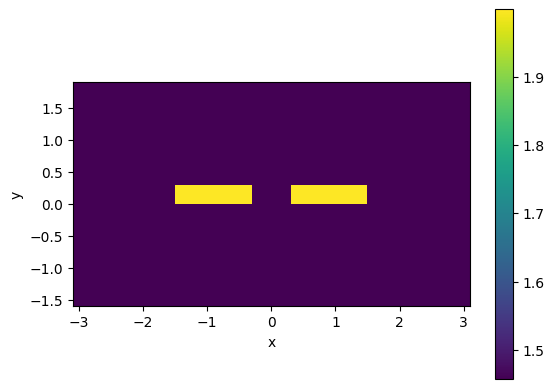

In [4]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-05-04 00:34:10.987 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.
[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

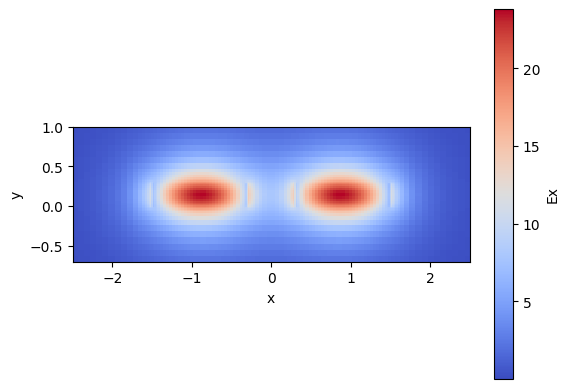

In [8]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

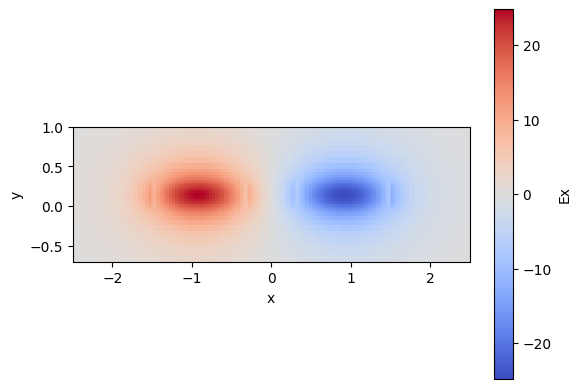

In [9]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

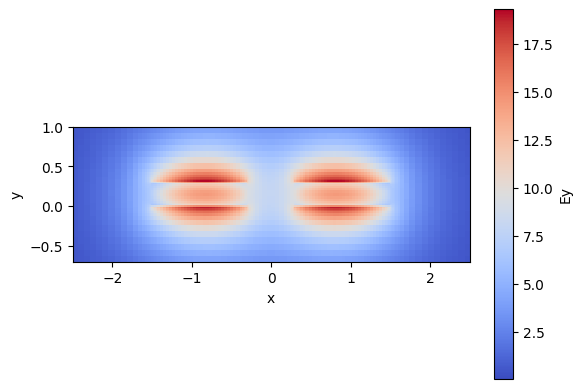

In [10]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

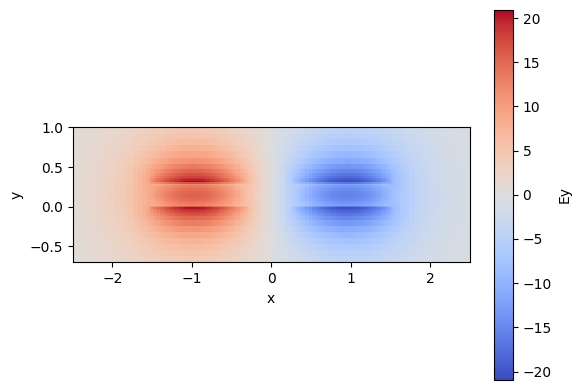

In [11]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [12]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536700753
52.26022367744142


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [13]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

2026-05-04 00:34:13.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_e9d8970c9a30f0a4.npz.


[118.6732366   60.86489512]


<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1470/190124028.py:35: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_title(f'Transfer Function: Mode TE ($L_{{\pi}}$ = {LPI[0]:.2f} $\mu m$)')
/tmp/ipykernel_1470/190124028.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title(f'Transfer Function: Mode TE ($L_{{\pi}}$ = {LPI[0]:.2f} $\mu m$)')
/tmp/ipykernel_1470/190124028.py:36: SyntaxWarning: invali

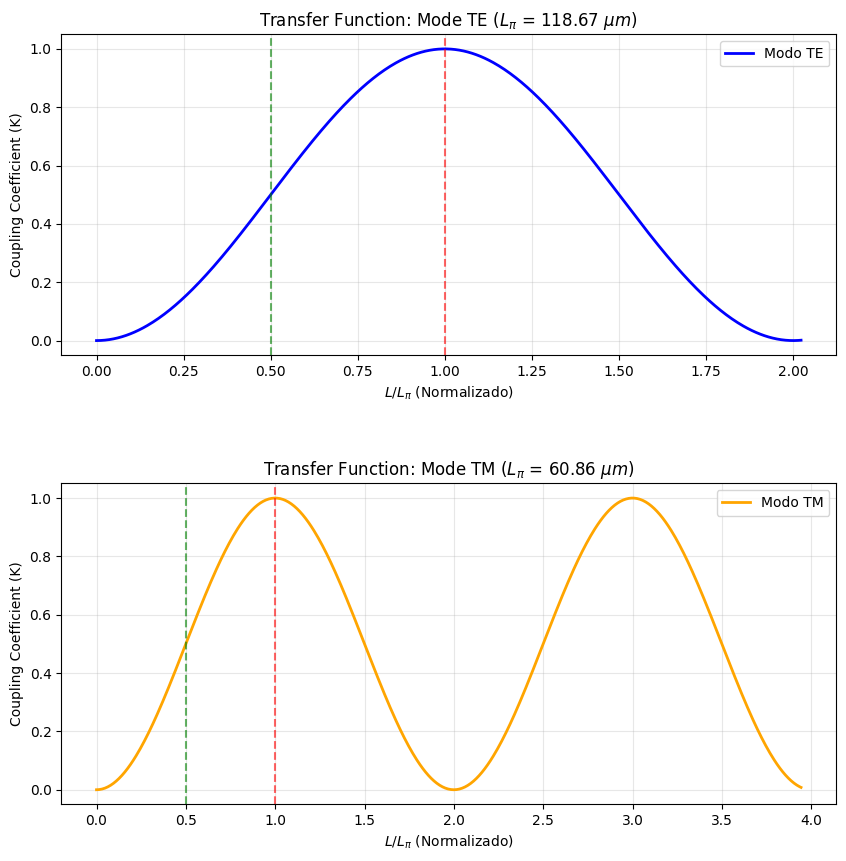

In [14]:
dcoupler_cs_2 = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1.5, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

LPI = dcoupler_cs_2.coupling_length()
print(LPI)
L = np.linspace(0, 240, 500)
LLPI_TE = L/LPI[0]
LLPI_TM = L/LPI[1]
K_TE = np.sin((np.pi * L) / (2 * LPI[0]))**2
K_TM = np.sin((np.pi * L) / (2 * LPI[1]))**2

# Configuramos la figura con dos subplots (uno arriba del otro)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

# --- PLOT MODO TE ---
ax1.plot(LLPI_TE, K_TE, color='blue', linewidth=2, label='Modo TE')
ax1.axvline(x=1.0, color='red', linestyle='--', alpha=0.6) # Marca transferencia completa
ax1.axvline(x=0.5, color='green', linestyle='--', alpha=0.6) # Marca 50/50
ax1.set_title(f'Transfer Function: Mode TE ($L_{{\pi}}$ = {LPI[0]:.2f} $\mu m$)')
ax1.set_xlabel('$L / L_{\pi}$ (Normalizado)')
ax1.set_ylabel('Coupling Coefficient (K)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- PLOT MODO TM ---
ax2.plot(LLPI_TM, K_TM, color='orange', linewidth=2, label='Modo TM')
ax2.axvline(x=1.0, color='red', linestyle='--', alpha=0.6)
ax2.axvline(x=0.5, color='green', linestyle='--', alpha=0.6)
ax2.set_title(f'Transfer Function: Mode TM ($L_{{\pi}}$ = {LPI[1]:.2f} $\mu m$)')
ax2.set_xlabel('$L / L_{\pi}$ (Normalizado)')
ax2.set_ylabel('Coupling Coefficient (K)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.show()

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [15]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605181689  µm


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


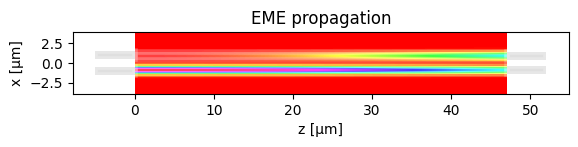

In [16]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



In [17]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.0, 1.0), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=3835.5 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)
dcoupler_cs.coupling_length()

LPI = dcoupler_cs.coupling_length()
print(LPI)
L = 10000 
LLPI_TE = L/LPI[0]
LLPI_TM = L/LPI[1]
K_TE = np.sin((np.pi * L) / (2 * LPI[0]))**2
K_TM = np.sin((np.pi * L) / (2 * LPI[1]))**2
print("K_TE =", K_TE)
print("K_TM =", K_TM)


2026-05-04 00:35:18.951 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ee7030d94f79d597.npz.


[157239.70513601  14442.31600332]
K_TE = 0.009946496390747213
K_TM = 0.7841642558438953


In [18]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.01
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 
lambda_c = 1.55

dcoupler_cs_shallow = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.0, 1.0), # Waveguide width
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=4925 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)
dcoupler_cs_shallow.coupling_length()

LPI = dcoupler_cs_shallow.coupling_length()
print(LPI)
L = 10000 
LLPI_TE = L/LPI[0]
LLPI_TM = L/LPI[1]
K_TE = np.sin((np.pi * L) / (2 * LPI[0]))**2
K_TM = np.sin((np.pi * L) / (2 * LPI[1]))**2
print("K_TE =", K_TE)
print("K_TM =", K_TM)

2026-05-04 00:35:19.107 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_8cdec11af677a70d.npz.
[157536.87089102    508.70222879]
K_TE = 0.009909131454050283
K_TM = 0.2620666754989276


## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [19]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-05-04 00:35:19.240 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [20]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

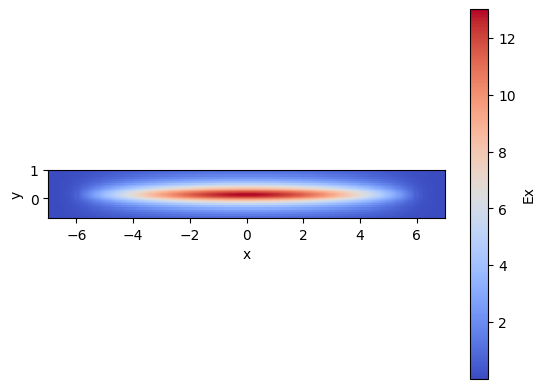

In [21]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

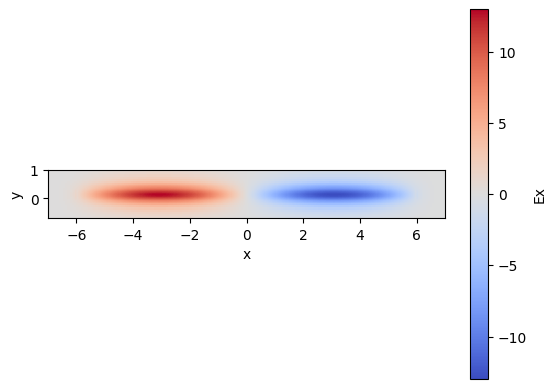

In [22]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

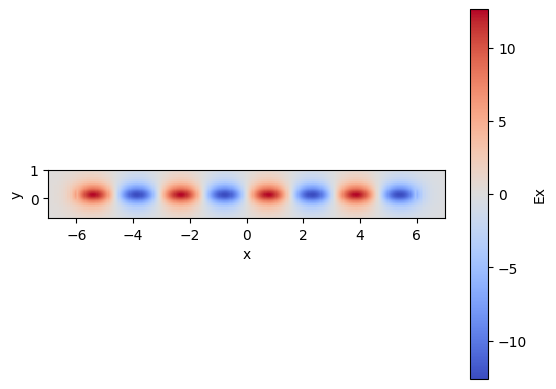

In [23]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [24]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794414357


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [25]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725655  µm


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


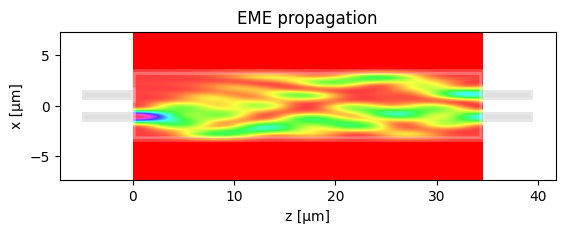

In [26]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/684 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.3000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9162
Excess loss [dB] =  0.3800
------------------------
Power over OUTs:  ['0.4670', '0.4492']
Ratio over OUTs ['0.5097', '0.4903']


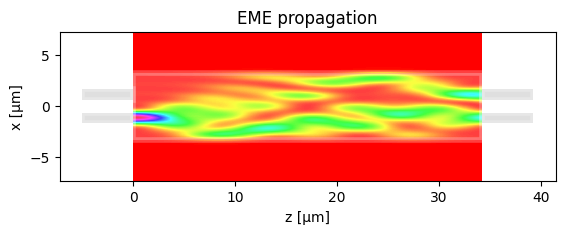

In [27]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.3  # STUDENT

# Run propagation
m.propagation()

### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [28]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.9 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725655  µm


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/684 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.3000
IO wg width 1.0000
IO wg width increment 0.9000
------------------------
Total power IN coupled 0.9969
Total OUT power: 0.9935
Excess loss [dB] =  0.0283
------------------------
Power over OUTs:  ['0.5056', '0.4880']
Ratio over OUTs ['0.5089', '0.4911']


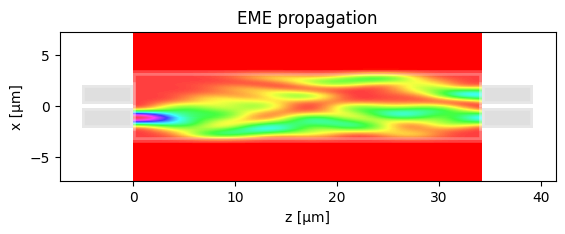

In [29]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.3 # STUDENT

# Run propagation
m.propagation()

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [30]:
m = MMI_EME()
m.MMI_width = 12   # MMI width
m.wg_width_dw = 0.9 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  219.13931544110972  µm


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/816 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -0.3000
IO wg width 1.0000
IO wg width increment 0.9000
------------------------
Total power IN coupled 0.9903
Total OUT power: 0.9752
Excess loss [dB] =  0.1089
------------------------
Power over OUTs:  ['0.2375', '0.2502', '0.2502', '0.2374']
Ratio over OUTs ['0.2435', '0.2565', '0.2565', '0.2434']


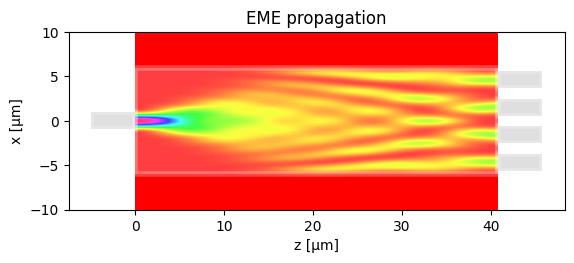

In [31]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([0]) #+ np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-4/6, -1/6, 1/6, 4/6]) + np.array([-3*dy, -4.5*dy, 4.5*dy, 3*dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (3/16)*L_pi  # STUDENT
m.dL_MMI = -0.3 # STUDENT

# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:45:28 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-05-04 00:45:28.567 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:45:57 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

...

2026-05-04 00:48:04.713 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_588db5a51611ad68.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

2026-05-04 00:48:09.705 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_19b93f644214da9a.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

2026-05-04 00:48:15.787 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_607bc461df88fcf3.npz.


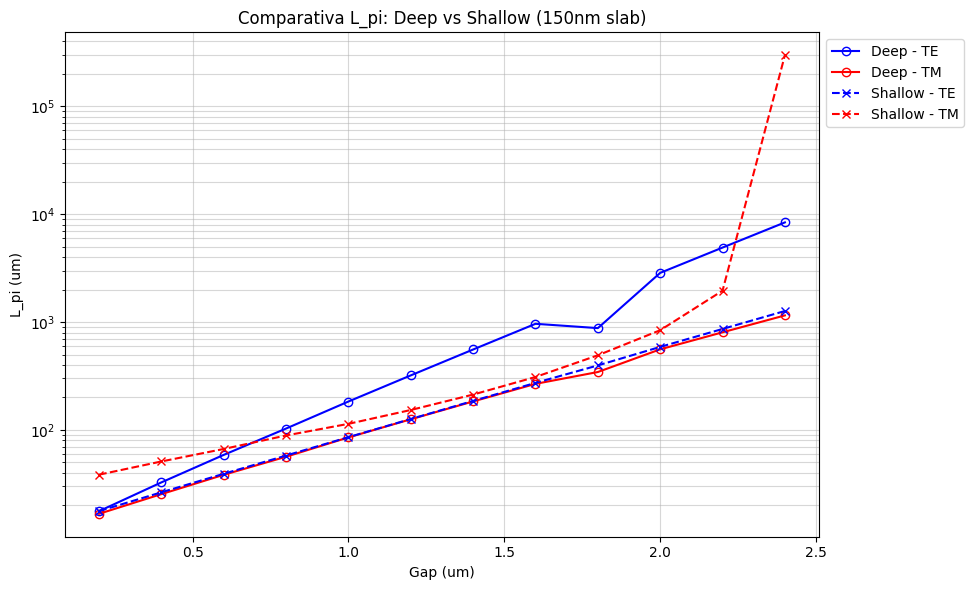

In [32]:

# 1. Definimos el vector de gaps (12 valores de 0.2 a 2.4 um)
gaps = np.linspace(0.2, 2.4, 12)

# 2. Inicializamos listas para ambas configuraciones y polarizaciones
l_pi_deep_TE, l_pi_deep_TM = [], []
l_pi_shallow_TE, l_pi_shallow_TM = [], []

# 3. Bucle para calcular los valores de ambos acopladores
for i in range(len(gaps)):
    gap_actual = gaps[i]
    
    # --- Configuración DEEP (slab = 0) ---
    deep_dcoupler = gt.modes.WaveguideCoupler(
        wavelength=1.55, 
        core_width=(1.0, 1.0), 
        gap=gap_actual,
        slab_thickness=0 * nm, 
        core_material='sin', 
        clad_material='sio2', 
        core_thickness=300 * nm, 
        num_modes=4, 
        cache_path='.cache/', 
        precision='double',
        max_grid_scaling=1.5, 
        grid_resolution=20 
    )
    
    # --- Configuración SHALLOW (slab = 150 nm) ---
    shallow_dcoupler = gt.modes.WaveguideCoupler(
        wavelength=1.55, 
        core_width=(1.0, 1.0), 
        gap=gap_actual,
        slab_thickness=150 * nm, 
        core_material='sin', 
        clad_material='sio2', 
        core_thickness=300 * nm, 
        num_modes=4, 
        cache_path='.cache/', 
        precision='double',
        max_grid_scaling=1.5, 
        grid_resolution=20 
    )
    
    # Obtención de resultados para Deep
    res_deep = deep_dcoupler.coupling_length()
    l_pi_deep_TE.append(res_deep[0])
    l_pi_deep_TM.append(res_deep[1])
    
    # Obtención de resultados para Shallow
    res_shallow = shallow_dcoupler.coupling_length()
    l_pi_shallow_TE.append(res_shallow[0])
    l_pi_shallow_TM.append(res_shallow[1])

# --- STUDENT. Plot goes here ---
plt.figure(figsize=(12, 6))

# Gráficas para DEEP (Líneas continuas)
plt.plot(gaps, l_pi_deep_TE, label='Deep - TE', color='blue', marker='o', markerfacecolor='none')
plt.plot(gaps, l_pi_deep_TM, label='Deep - TM', color='red', marker='o', markerfacecolor='none')

# Gráficas para SHALLOW (Líneas discontinuas)
plt.plot(gaps, l_pi_shallow_TE, label='Shallow - TE', color='blue', linestyle='--', marker='x')
plt.plot(gaps, l_pi_shallow_TM, label='Shallow - TM', color='red', linestyle='--', marker='x')

plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.title("Comparativa L_pi: Deep vs Shallow (150nm slab)")
plt.yscale('log') # Opcional: escala logarítmica si los valores crecen mucho con el gap
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

### E2. Directional coupler wavelength dependence

2026-05-04 00:49:18.980 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_13c27ad65d7417a2.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:49:32 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

2026-05-04 00:49:32.572 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_1603a8ec7701e9f2.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

...

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

2026-05-04 00:51:16.886 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_97623af69138ade0.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:51:18 CEST WARNING: Mode field at frequency index 0, mode index 3 does not   
              decay at the plane boundaries.                                    

2026-05-04 00:51:18.275 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_8906f01077c2e704.npz.


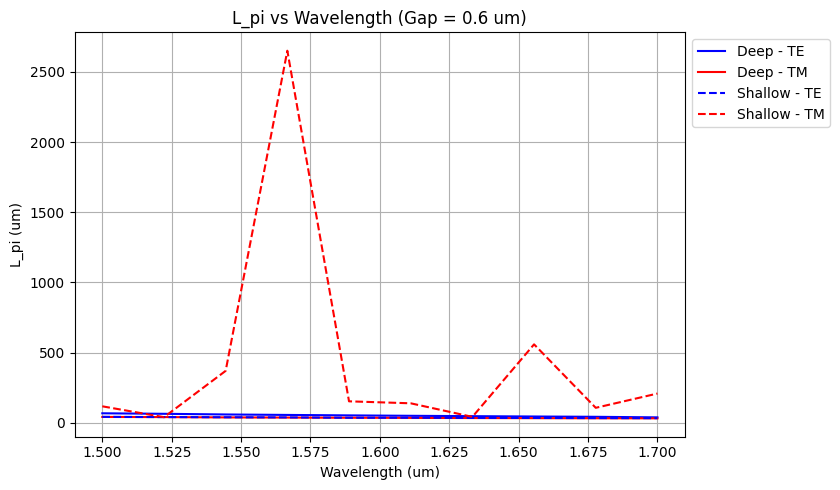

In [34]:
# 1. Definimos el vector de longitud de onda
wavelengths = np.linspace(1.5, 1.7, 10) 

# Inicializamos listas para guardar los resultados
l_pi_deep_TE, l_pi_deep_TM = [], []
l_pi_shallow_TE, l_pi_shallow_TM = [], []

# 2. Bucle para recorrer cada longitud de onda
for wl in wavelengths:
    # Configuración DEEP
    deep_dcoupler = gt.modes.WaveguideCoupler(
        wavelength=wl, 
        core_width=(1.0, 1.0), 
        gap=600 * nm,
        slab_thickness=0 * nm, 
        core_material='sin', 
        clad_material='sio2', 
        core_thickness=300 * nm, 
        num_modes=4, 
        cache_path='.cache/', 
        precision='double',
        grid_resolution=20 
    )
    
    # Configuración SHALLOW
    shallow_dcoupler = gt.modes.WaveguideCoupler(
        wavelength=wl, 
        core_width=(1.0, 1.0), 
        gap=600 * nm,
        slab_thickness=150 * nm, 
        core_material='sin', 
        clad_material='sio2', 
        core_thickness=300 * nm, 
        num_modes=4, 
        cache_path='.cache/', 
        precision='double',
        grid_resolution=20 
    )

    # Extraemos LPI (índice 0=TE, 1=TM)
    res_deep = deep_dcoupler.coupling_length()
    l_pi_deep_TE.append(res_deep[0])
    l_pi_deep_TM.append(res_deep[1])
    
    res_shallow = shallow_dcoupler.coupling_length()
    l_pi_shallow_TE.append(res_shallow[0])
    l_pi_shallow_TM.append(res_shallow[1])

# 3. Gráfica combinada
plt.figure(figsize=(10, 5))

# Plot Deep (Línea continua)
plt.plot(wavelengths, l_pi_deep_TE, label='Deep - TE', color='blue')
plt.plot(wavelengths, l_pi_deep_TM, label='Deep - TM', color='red')

# Plot Shallow (Línea discontinua)
plt.plot(wavelengths, l_pi_shallow_TE, label='Shallow - TE', color='blue', linestyle='--')
plt.plot(wavelengths, l_pi_shallow_TM, label='Shallow - TM', color='red', linestyle='--')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title("L_pi vs Wavelength (Gap = 0.6 um)")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E3. MMI coupler wavelength dependence

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:52:18 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-04 00:52:15.876 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9a2f1ddbafc80a93.npz.


/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:52:33 CEST WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

...

00:58:40 CEST WARNING: Mode field at frequency index 0, mode index 8 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

00:58:41 CEST WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

2026-05-04 00:58:41.176 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_7a54b34d317d0af0.npz.


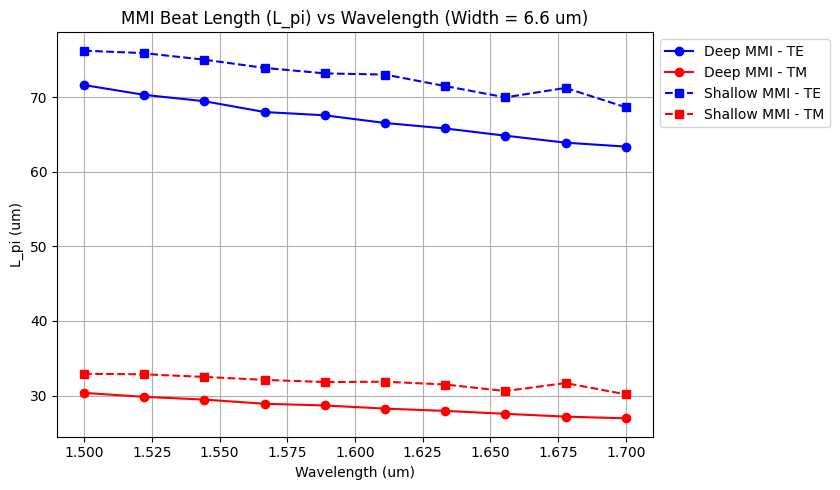

In [35]:
# Parámetros fijos
mmi_body_w = 6.6 
# STUDENT code: Definimos el rango de longitudes de onda (1.5 a 1.7 um)
lambda_c = np.linspace(1.5, 1.7, 10) 

# Inicializamos listas para almacenar resultados
L_pi_deep_TE, L_pi_deep_TM = [], []
L_pi_shallow_TE, L_pi_shallow_TM = [], []

for wl in lambda_c:
    # --- Simulación DEEP (slab = 0) ---
    mmi_deep = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=wl,
        num_modes=15,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    
    # STUDENT code: Cálculo de L_pi para Deep
    # L_pi = lambda / (2 * (n_eff0 - n_eff1))
    # Para TE (índices 0 y 1)
    dn_TE_deep = mmi_deep.n_eff[0].real - mmi_deep.n_eff[1].real
    L_pi_deep_TE.append(wl / (2 * dn_TE_deep))
    
    # Para TM (índices 2 y 3, asumiendo que el solver los ordena por n_eff)
    dn_TM_deep = mmi_deep.n_eff[2].real - mmi_deep.n_eff[3].real
    L_pi_deep_TM.append(wl / (2 * dn_TM_deep))

    # --- Simulación SHALLOW (slab = 150 nm) ---
    mmi_shallow = gt.modes.Waveguide(
        core_width=mmi_body_w,
        core_thickness=300 * nm,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=wl,
        num_modes=15,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    
    # Cálculo de L_pi para Shallow
    dn_TE_sha = mmi_shallow.n_eff[0].real - mmi_shallow.n_eff[1].real
    L_pi_shallow_TE.append(wl / (2 * dn_TE_sha))
    
    dn_TM_sha = mmi_shallow.n_eff[2].real - mmi_shallow.n_eff[3].real
    L_pi_shallow_TM.append(wl / (2 * dn_TM_sha))

# --- STUDENT plot here ---
plt.figure(figsize=(10, 5))

# Graficamos Deep
plt.plot(lambda_c, L_pi_deep_TE, 'o-', label='Deep MMI - TE', color='blue')
plt.plot(lambda_c, L_pi_deep_TM, 'o-', label='Deep MMI - TM', color='red')

# Graficamos Shallow
plt.plot(lambda_c, L_pi_shallow_TE, 's--', label='Shallow MMI - TE', color='blue')
plt.plot(lambda_c, L_pi_shallow_TM, 's--', label='Shallow MMI - TM', color='red')

plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi (um)")
plt.title(f"MMI Beat Length (L_pi) vs Wavelength (Width = {mmi_body_w} um)")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E4. MMI coupler body width dependence

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

00:59:30 CEST WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

...

/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/usuario/cifoin-lab2/cifoin-lab2/.venv/lib/python3.12/site-pac

01:04:47 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 16 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 17 does not  
              decay at the plane boundaries.                                    

2026-05-04 01:04:47.430 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_8fa92fbb6a06489f.npz.


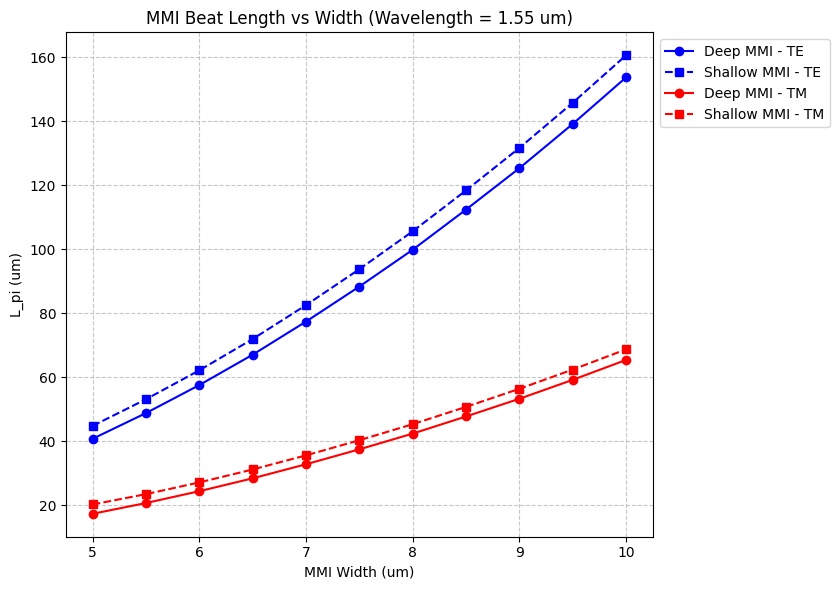

In [36]:
# 1. Parámetros fijos
lambda_c = 1.55
# Vector de anchos: de 5 a 10 um con saltos de 0.5 (11 puntos)
mmi_widths = np.arange(5, 10.5, 0.5)

# Inicializamos listas para los resultados
l_pi_deep_TE, l_pi_deep_TM = [], []
l_pi_shallow_TE, l_pi_shallow_TM = [], []

# 2. Bucle de barrido en el ancho (Width)
for w in mmi_widths:
    
    # --- Simulación DEEP (slab = 0) ---
    mmi_deep = gt.modes.Waveguide(
        core_width=w,
        core_thickness=300 * nm,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=20, # Aumentamos modos por si el ancho es muy grande
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    
    # Cálculo L_pi TE (Deep)
    dn_TE_d = mmi_deep.n_eff[0].real - mmi_deep.n_eff[1].real
    l_pi_deep_TE.append(lambda_c / (2 * dn_TE_d))
    
    # Cálculo L_pi TM (Deep) - Usamos índices 2 y 3 para la otra polarización
    dn_TM_d = mmi_deep.n_eff[2].real - mmi_deep.n_eff[3].real
    l_pi_deep_TM.append(lambda_c / (2 * dn_TM_d))

    # --- Simulación SHALLOW (slab = 150 nm) ---
    mmi_shallow = gt.modes.Waveguide(
        core_width=w,
        core_thickness=300 * nm,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=20,
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    
    # Cálculo L_pi TE (Shallow)
    dn_TE_s = mmi_shallow.n_eff[0].real - mmi_shallow.n_eff[1].real
    l_pi_shallow_TE.append(lambda_c / (2 * dn_TE_s))
    
    # Cálculo L_pi TM (Shallow)
    dn_TM_s = mmi_shallow.n_eff[2].real - mmi_shallow.n_eff[3].real
    l_pi_shallow_TM.append(lambda_c / (2 * dn_TM_s))

# 3. Generación de la gráfica
plt.figure(figsize=(10, 6))

# Graficamos resultados TE (Azul)
plt.plot(mmi_widths, l_pi_deep_TE, 'o-', label='Deep MMI - TE', color='blue')
plt.plot(mmi_widths, l_pi_shallow_TE, 's--', label='Shallow MMI - TE', color='blue')

# Graficamos resultados TM (Rojo)
plt.plot(mmi_widths, l_pi_deep_TM, 'o-', label='Deep MMI - TM', color='red')
plt.plot(mmi_widths, l_pi_shallow_TM, 's--', label='Shallow MMI - TM', color='red')

plt.xlabel("MMI Width (um)")
plt.ylabel("L_pi (um)")
plt.title(f"MMI Beat Length vs Width (Wavelength = {lambda_c} um)")
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points